In [1]:
import os

if os.getcwd().split("/")[-1] != "neurolib":
    os.chdir('..')

os.chdir('..')
datadir = os.path.join(os.getcwd(), "neurolib", "whole-brain")

print(datadir)

/mnt/antares_raid/home/salfenmoser/neurolib/neurolib/whole-brain


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.io
from numba.typed import Dict
from numba.core import types
import pickle

from neurolib.models.wc import WCModel
from neurolib.utils.stimulus import ZeroInput
from neurolib.control.optimal_control import oc_wc, cost_functions

import matplotlib as mpl
label_size= 20
mpl.rcParams['xtick.labelsize'] = label_size
mpl.rcParams['ytick.labelsize'] = label_size
mpl.rcParams['font.size'] = label_size
mpl.rcParams['axes.titlesize'] = label_size
mpl.rcParams['axes.titlesize'] = label_size
mpl.rcParams['figure.titlesize'] = label_size
mpl.rcParams['lines.linewidth'] = 1


# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2

weights = Dict.empty(
        key_type=types.unicode_type,
        value_type=types.float64,
    )

weights["w_2"] = 0.0
weights["w_1"] = 0.0
weights["w_1T"] = 0.0
weights["w_1D"] = 1.0

In [3]:
N = 100

folders = ["NAP_002", "NAP_003", "NAP_005", "NAP_007", "NAP_009", "NAP_010", "NAP_011", "NAP_012", "NAP_013", "NAP_014", "NAP_015", "NAP_016", "NAP_018", "NAP_020", "NAP_022", "NAP_024", "NAP_025", "NAP_026", "NAP_027", "NAP_028", "NAP_029", "NAP_031", "NAP_032", "NAP_033", "NAP_035", "NAP_036"]
cmat_sum = np.zeros((N,N))
dmat_sum = np.zeros((N,N))

for f in folders:
    path = os.path.join(os.getcwd(), "data", "structural_data", "Sch100", f, "SC", "DTI_CM.mat")
    cmat_sum += scipy.io.loadmat(path)["SC"]
    path = os.path.join(os.getcwd(), "data", "structural_data", "Sch100", f, "SC", "DTI_LEN.mat")
    dmat_sum += scipy.io.loadmat(path)["LEN"]

cmat_av = cmat_sum/len(folders)
dmat_av = dmat_sum/len(folders)

In [4]:
coords = [[1.6, 0.0], [1.7, 0.1]] #1st: multistable     // 2nd: unistable synchronized

data_0_L1, data_1_L1, data_2_L1 = dict(), dict(), dict()
data_0_L1["coordinates"] = coords[0]
data_1_L1["coordinates"] = coords[0]
data_2_L1["coordinates"] = coords[1]
lng = int(4*1e3)

for d in [data_0_L1, data_1_L1, data_2_L1]:
    d["weights"] = np.zeros((100))
    d["control"] = [None] * len(data_0_L1["weights"])
    d["state"] = [None] * len(data_0_L1["weights"])
    d["init_state"] = None
    d["energy_input"] = np.zeros((len(d["weights"])))
    d["sync_cost"] = np.zeros((len(d["weights"])))
    d["state_uncontrolled"] = np.zeros((N,2,lng))

data_1_L1["weights"] *= -1

In [5]:
def setparams(model):
    model.params.c_excinh = 12  # local E-I coupling
    model.params.signalV = 80.0
    model.params.K_gl = 0.5  # global coupling strength
    model.params.a_exc = 1.  # excitatory gain
    model.params.a_inh = 1.  # inhibitory gain
    model.params.mu_exc = 5.0  # excitatory firing threshold
    model.params.mu_inh = 5.0  # inhibitory firing threshold

def plot_control(c, s, dur, dt, fat=[], filename=None, title=None):
    fig, ax = plt.subplots(2,1, figsize=(32,8), sharex=True)
    time_array = np.arange(0, dur+dt, dt)

    cmax = np.amax(np.abs(c))
    y1lim = [-cmax* 1.1, cmax* 1.1]

    for n in range(N):
        if n in fat:
            ax[0].plot(time_array, s[n,0,:], linewidth=4)
        else:
            ax[0].plot(time_array, s[n,0,:])
        ax[1].plot(time_array, c[n,:])

    ax[0].set_xlim(0, dur)

    ax[1].set_ylim(y1lim)

    ax[1].set_xlabel("Time")
    ax[0].set_ylabel("Activity")
    ax[1].set_ylabel("Control")

    plt.subplots_adjust(
                    wspace=0.15,
                    hspace=0.1)
    
    fig.align_ylabels([ax[0]])
    
    if title is not None:
        fig.suptitle(title)

    if filename is not None:
        plt.savefig(filename, bbox_inches='tight', dpi=200)

    plt.show()
    return

def get_results(d, wi, mc):
    d["control"][wi] = mc.control.copy()
    d["state"][wi] = mc.get_xs()
    d["energy_input"][wi] = cost_functions.control_strength_cost(mc.control, weights, dt)
    d["sync_cost"][wi] = (mc.compute_total_cost() - d["energy_input"][wi])/d["weights"][wi]

def dump_data():
    with open(os.path.join(datadir, 'wb_L1_cc_all_0.pickle'), 'wb') as f:
        pickle.dump(data_0_L1, f)

controlmat = np.ones((N))
costmat = np.ones((N))

duration = 400.
target_period = 1

int0 = 0
int1 = None

max_cntrl = 5
pr = np.arange(0,101,1)
dt = 0.1

------------------- seed =  1


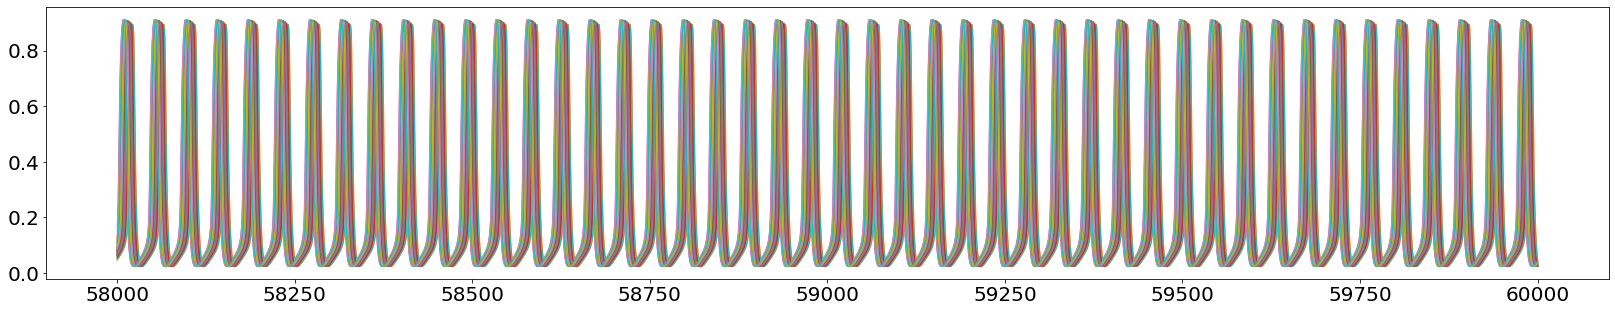

------------------- seed =  25


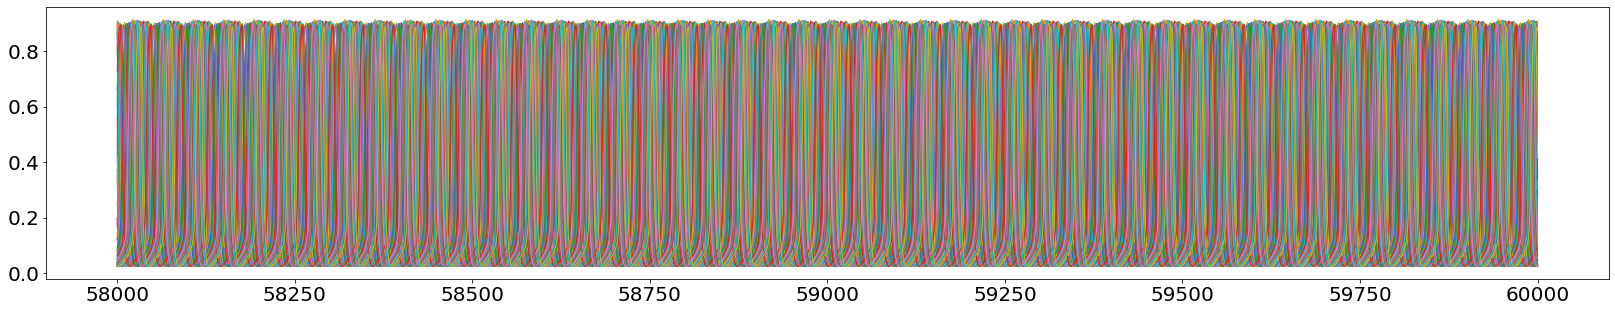

In [8]:
point = 0
seed = [1, 25]

#for s in np.arange(0,50,1):
for i_s, s in enumerate(seed):

    print("------------------- seed = ", s)

    model = WCModel(Cmat=cmat_av, Dmat=dmat_av, seed=s)
    testd = 60.*1e3     # needs to stay 60!!!!!
    dt = model.params.dt
    model.params.duration = testd
    model.params.seed = s
    setparams(model)

    #zero_input = ZeroInput().generate_input(duration=testd+model.params.dt, dt=model.params.dt)
    #input = zero_input.copy()
    #input[0,int(0.*1e3/dt):int(5.*1e3/dt)] = 1.

    #print(model.params.exc_init[0,0])

    model.params.exc_ext_baseline = data_0_L1["coordinates"][0]
    model.params.exc_inh_baseline = data_0_L1["coordinates"][1]

    #model.params.exc_ext = input
    model.run()

    plt.figure(figsize=(28,5))

    for n in range(N):
        plt.plot(model.t[-int(2.*1e3/dt):], model.exc[n,-int(2.*1e3/dt):], linewidth=1)
    plt.show()

    nmaxdelay = model.getMaxDelay()
    einit = np.zeros((N, nmaxdelay+1))
    iinit = np.zeros((N, nmaxdelay+1))

    state = np.zeros((N,2,lng))

    for n in range(N):
        einit[n,:] = model.exc[n,-nmaxdelay-1:]
        iinit[n,:] = model.inh[n,-nmaxdelay-1:]
        state[n,0,:] = model.exc[n, -lng:]

    if i_s == 0:
        data_0_L1["init_state"] = [einit, iinit]
        data_0_L1["state_uncontrolled"] = state.copy()
    else:
        data_1_L1["init_state"] = [einit, iinit]
        data_1_L1["state_uncontrolled"] = state.copy()

In [6]:
with open(os.path.join(datadir, 'wb_L1_cc_all_0.pickle'), 'rb') as f:
    data_read = pickle.load(f)

data_0_L1 = data_read

In [11]:
print(data_0_L1["weights"])

[  -2.   -4.   -6.   -8.  -10.  -12.  -14.  -16.  -18.  -20.  -22.  -24.
  -26.  -28.  -30.  -32.  -34.  -36.  -38.  -40.  -42.  -44.  -46.  -48.
  -50.  -52.  -54.  -56.  -58.  -60.  -62.  -64.  -66.  -68.  -70.  -72.
  -74.  -76.  -78.  -80.  -82.  -84.  -86.  -88.  -90.  -92.  -94.  -96.
  -98. -100. -102. -104. -106. -108. -110. -112. -114. -116. -118. -120.
 -122. -124. -126. -128. -130. -132. -134. -136. -138. -140. -142. -144.
 -146. -148. -150. -152. -154. -156. -158. -160. -162. -164. -166. -168.
 -170. -172. -174. -176. -178. -180. -182. -184. -186. -188. -190. -192.
 -194. -196. -198. -200.]


In [10]:
data_0_L1["weights"][0] = -2.
for n in range(N-1):
    data_0_L1["weights"][n+1] = data_0_L1["weights"][n] - 2.

In [7]:
def optimize_model(model, step_exp_array, wi, it):
    for k in step_exp_array:
        model.zero_step_encountered = False
        model.step = 10.**(k)
        model.optimize(it)

        get_results(d, wi, model)
        dump_data()

In [8]:
convergence = np.zeros((100))

------------------------------------------------------------ wi =  3 -8.0
Optimal control with target oscillation period
Compute control for a deterministic system
Cost in iteration 0: 4.997998056322832
Final cost : 4.997998056322832
Compute control for a deterministic system
Cost in iteration 0: 3.935589481816455
Final cost : 3.935589481816455
Compute control for a deterministic system
Cost in iteration 0: 3.935589481816455
Cost in iteration 1: 3.9355819472353932
Cost in iteration 2: 3.935581947235382
Cost in iteration 3: 3.935581947235382
Cost in iteration 4: 3.935581947235382
Converged in iteration 4 with cost 3.935581947235382
Final cost : 3.935581947235382
Compute control for a deterministic system
Cost in iteration 0: 3.935581947235382
Cost in iteration 1: 3.935581947235382
Cost in iteration 2: 3.935581947235382
Converged in iteration 2 with cost 3.935581947235382
Final cost : 3.935581947235382
Compute control for a deterministic system
Cost in iteration 0: 3.935581947235382
Cost

Cost in iteration 1: 3.924094972027134
Cost in iteration 2: 3.924094972027134
Cost in iteration 3: 3.924094972027134
Converged in iteration 3 with cost 3.924094972027134
Final cost : 3.924094972027134
Compute control for a deterministic system
Cost in iteration 0: 3.924094972027134
Cost in iteration 1: 3.924094972027134
Cost in iteration 2: 3.924094972027134
Converged in iteration 2 with cost 3.924094972027134
Final cost : 3.924094972027134
Compute control for a deterministic system
Cost in iteration 0: 3.924094972027134
Cost in iteration 1: 3.924094972027134
Cost in iteration 2: 3.924094972027134
Converged in iteration 2 with cost 3.924094972027134
Final cost : 3.924094972027134
Compute control for a deterministic system
Cost in iteration 0: 3.924094972027134
Cost in iteration 1: 3.915034473832552
Cost in iteration 2: 3.9150344738325504
Cost in iteration 3: 3.9150344738325504
Cost in iteration 4: 3.9150344738325504
Converged in iteration 4 with cost 3.9150344738325504
Final cost : 3.9

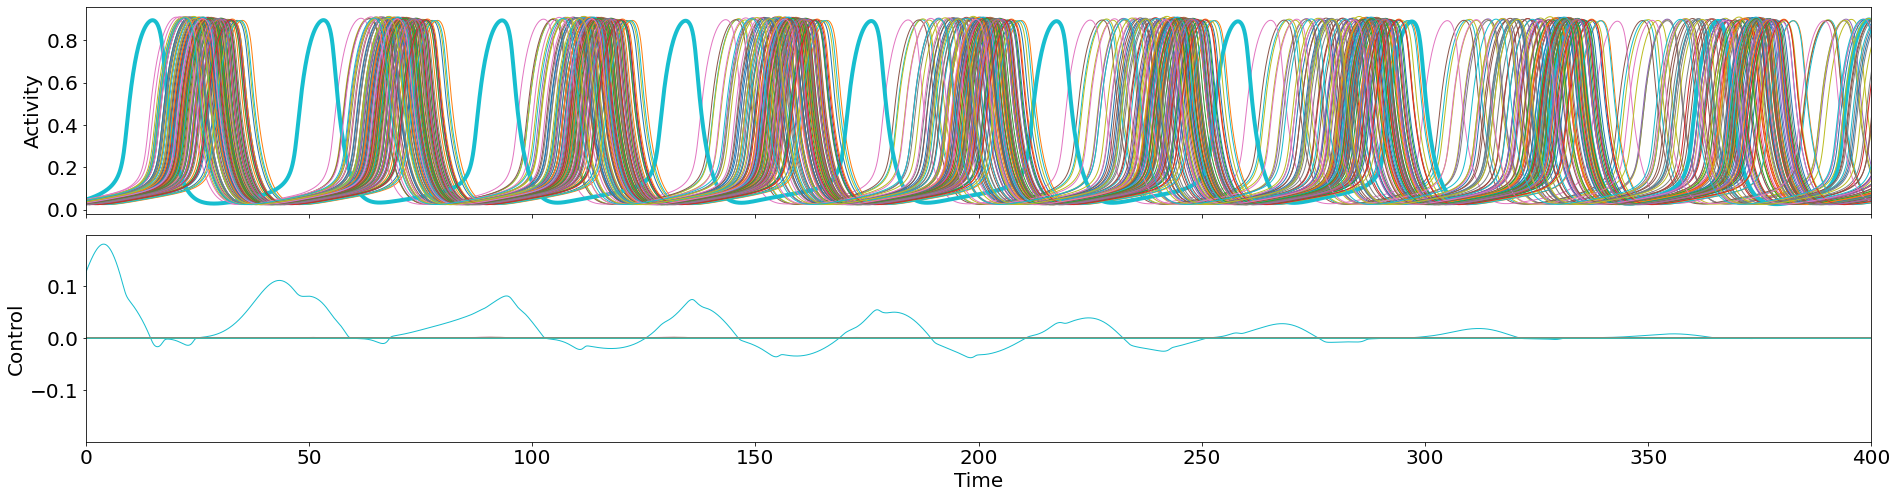

------------------------------------------------------------ wi =  5 -12.0
Optimal control with target oscillation period
Compute control for a deterministic system
Cost in iteration 0: 7.496997084484236
Final cost : 7.496997084484236
Compute control for a deterministic system
Cost in iteration 0: 5.110182035625099
Final cost : 5.110182035625099
Compute control for a deterministic system
Cost in iteration 0: 5.110182035625099
Cost in iteration 1: 5.110172825438725
Cost in iteration 2: 5.110172825438725
Cost in iteration 3: 5.110172825438725
Converged in iteration 3 with cost 5.110172825438725
Final cost : 5.110172825438725
Compute control for a deterministic system
Cost in iteration 0: 5.110172825438725
Cost in iteration 1: 5.110172825438725
Cost in iteration 2: 5.110172825438725
Converged in iteration 2 with cost 5.110172825438725
Final cost : 5.110172825438725
Compute control for a deterministic system
Cost in iteration 0: 5.110172825438725
Cost in iteration 1: 5.110172825438725
Cost

Cost in iteration 1: 5.110109328396483
Cost in iteration 2: 5.110109328396477
Cost in iteration 3: 5.110109328396474
Cost in iteration 4: 5.110109328396474
Cost in iteration 5: 5.110109328396474
Converged in iteration 5 with cost 5.110109328396474
Final cost : 5.110109328396474
Compute control for a deterministic system
Cost in iteration 0: 5.110109328396474
Cost in iteration 1: 5.110109328396474
Cost in iteration 2: 5.110109328396474
Converged in iteration 2 with cost 5.110109328396474
Final cost : 5.110109328396474
Compute control for a deterministic system
Cost in iteration 0: 5.110109328396474
Cost in iteration 1: 5.110109328396474
Cost in iteration 2: 5.110109328396474
Converged in iteration 2 with cost 5.110109328396474
Final cost : 5.110109328396474
Compute control for a deterministic system
Cost in iteration 0: 5.110109328396474
Cost in iteration 1: 5.110109328396474
Cost in iteration 2: 5.110109328396474
Converged in iteration 2 with cost 5.110109328396474
Final cost : 5.11010

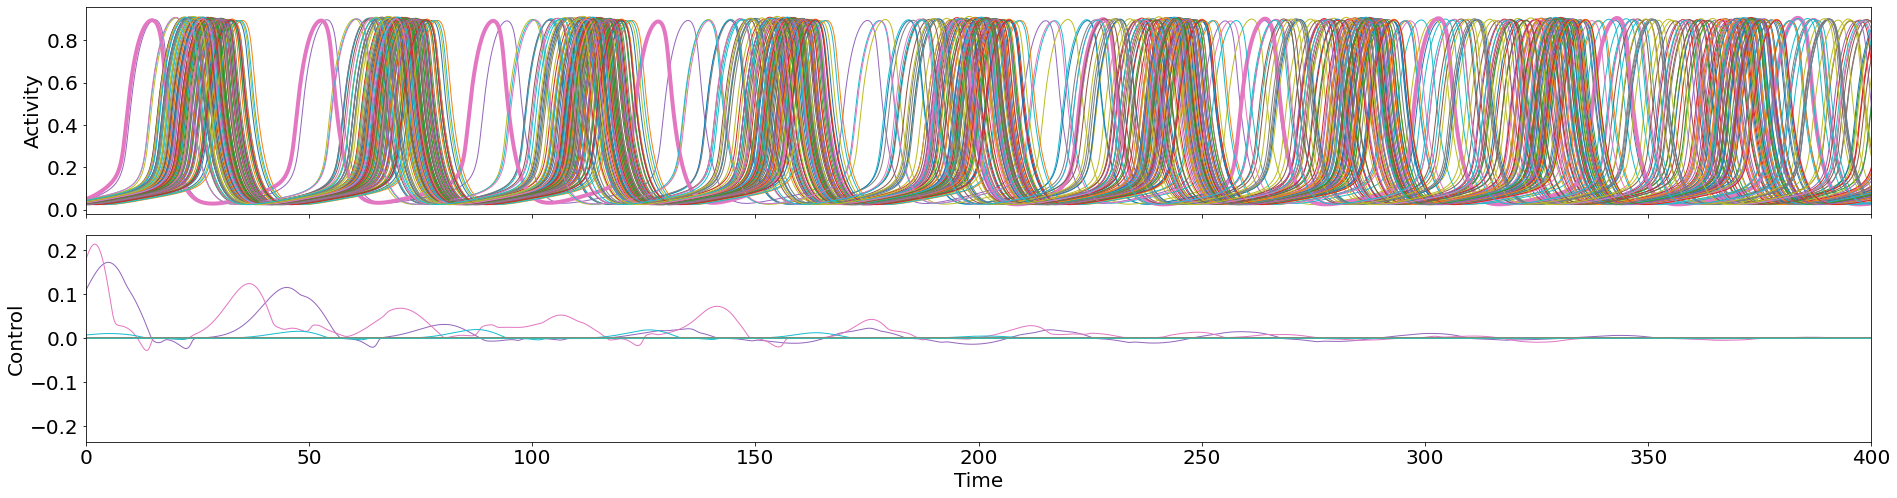

------------------------------------------------------------ wi =  10 -22.0
Optimal control with target oscillation period
Compute control for a deterministic system
Cost in iteration 0: 13.74449465488777
Final cost : 13.74449465488777
Compute control for a deterministic system
Cost in iteration 0: 6.8863901757951735
Final cost : 6.8863901757951735
Compute control for a deterministic system
Cost in iteration 0: 6.8863901757951735
Cost in iteration 1: 6.886356870076721
Cost in iteration 2: 6.886356870076721
Cost in iteration 3: 6.886356870076721
Converged in iteration 3 with cost 6.886356870076721
Final cost : 6.886356870076721
Compute control for a deterministic system
Cost in iteration 0: 6.886356870076721
Cost in iteration 1: 6.886356870076721
Cost in iteration 2: 6.886356870076721
Converged in iteration 2 with cost 6.886356870076721
Final cost : 6.886356870076721
Compute control for a deterministic system
Cost in iteration 0: 6.886356870076721
Cost in iteration 1: 6.886356870076721


Compute control for a deterministic system
Cost in iteration 0: 6.826667281569145
Cost in iteration 1: 6.826664552095855
Cost in iteration 2: 6.8266645520958456
Cost in iteration 3: 6.8266645520958456
Cost in iteration 4: 6.8266645520958456
Converged in iteration 4 with cost 6.8266645520958456
Final cost : 6.8266645520958456
Compute control for a deterministic system
Cost in iteration 0: 6.8266645520958456
Cost in iteration 1: 6.8266645520958456
Cost in iteration 2: 6.8266645520958456
Converged in iteration 2 with cost 6.8266645520958456
Final cost : 6.8266645520958456
Compute control for a deterministic system
Cost in iteration 0: 6.8266645520958456
Cost in iteration 1: 6.8266645520958456
Cost in iteration 2: 6.8266645520958456
Converged in iteration 2 with cost 6.8266645520958456
Final cost : 6.8266645520958456
Compute control for a deterministic system
Cost in iteration 0: 6.8266645520958456
Cost in iteration 1: 6.824416453796389
Cost in iteration 2: 6.824416453796383
Cost in iterat

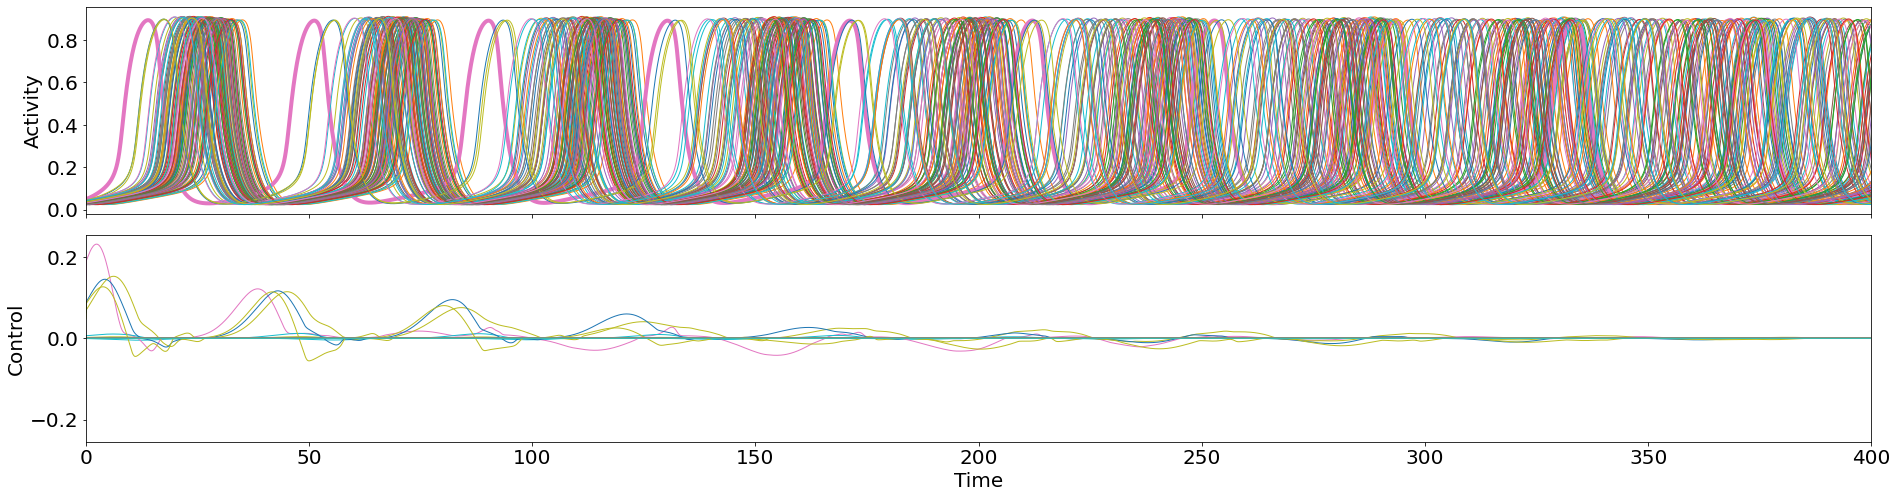

------------------------------------------------------------ wi =  15 -32.0
Optimal control with target oscillation period
Compute control for a deterministic system
Cost in iteration 0: 19.991992225291327
Final cost : 19.991992225291327
Compute control for a deterministic system
Cost in iteration 0: 8.644393606795937
Final cost : 8.644393606795937
Compute control for a deterministic system
Cost in iteration 0: 8.644393606795937
Cost in iteration 1: 8.644377876673756
Cost in iteration 2: 8.644377876673756
Cost in iteration 3: 8.644377876673756
Converged in iteration 3 with cost 8.644377876673756
Final cost : 8.644377876673756
Compute control for a deterministic system
Cost in iteration 0: 8.644377876673756
Cost in iteration 1: 8.644377876673756
Cost in iteration 2: 8.644377876673756
Converged in iteration 2 with cost 8.644377876673756
Final cost : 8.644377876673756
Compute control for a deterministic system
Cost in iteration 0: 8.644377876673756
Cost in iteration 1: 8.644377876673756
C

Compute control for a deterministic system
Cost in iteration 0: 8.639849279265631
Cost in iteration 1: 8.639827663110315
Cost in iteration 2: 8.639827663110315
Cost in iteration 3: 8.639827663110315
Converged in iteration 3 with cost 8.639827663110315
Final cost : 8.639827663110315
Compute control for a deterministic system
Cost in iteration 0: 8.639827663110315
Cost in iteration 1: 8.639827663110315
Cost in iteration 2: 8.639827663110315
Converged in iteration 2 with cost 8.639827663110315
Final cost : 8.639827663110315
Compute control for a deterministic system
Cost in iteration 0: 8.639827663110315
Cost in iteration 1: 8.639827663110315
Cost in iteration 2: 8.639827663110315
Converged in iteration 2 with cost 8.639827663110315
Final cost : 8.639827663110315
Compute control for a deterministic system
Cost in iteration 0: 8.639827663110315
Cost in iteration 1: 8.639312823175787
Cost in iteration 2: 8.639312823175784
Cost in iteration 3: 8.639312823175784
Cost in iteration 4: 8.6393128

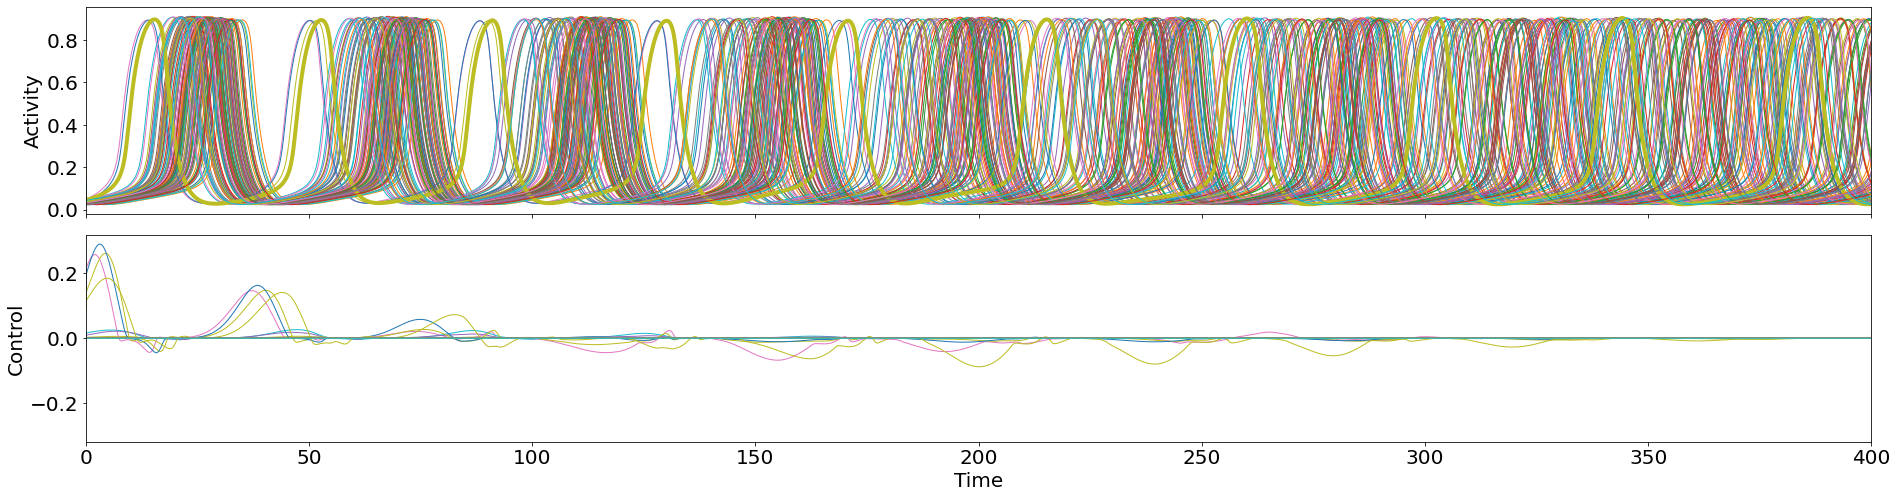

------------------------------------------------------------ wi =  20 -42.0
Optimal control with target oscillation period
Compute control for a deterministic system
Cost in iteration 0: 26.239489795694823
Final cost : 26.239489795694823
Compute control for a deterministic system
Cost in iteration 0: 11.39200072831644
Final cost : 11.39200072831644
Compute control for a deterministic system
Cost in iteration 0: 11.39200072831644
Cost in iteration 1: 11.391989947375802
Cost in iteration 2: 11.391989947375798
Cost in iteration 3: 11.39198994737576
Cost in iteration 4: 11.39198994737576
Cost in iteration 5: 11.39198994737576
Converged in iteration 5 with cost 11.39198994737576
Final cost : 11.39198994737576
Compute control for a deterministic system
Cost in iteration 0: 11.39198994737576
Cost in iteration 1: 11.39198994737576
Cost in iteration 2: 11.39198994737576
Converged in iteration 2 with cost 11.39198994737576
Final cost : 11.39198994737576
Compute control for a deterministic system

Cost in iteration 3: 11.242249329609997
Cost in iteration 4: 11.242249329609997
Cost in iteration 5: 11.242249329609876
Cost in iteration 6: 11.242249329609875
Final cost : 11.242249329609875
Compute control for a deterministic system
Cost in iteration 0: 11.242249329609875
Cost in iteration 1: 11.242238620130664
Cost in iteration 2: 11.242238620130664
Cost in iteration 3: 11.242238620130664
Cost in iteration 4: 11.242238620130664
Cost in iteration 5: 11.242238620130664
Converged in iteration 5 with cost 11.242238620130664
Final cost : 11.242238620130664
Compute control for a deterministic system
Cost in iteration 0: 11.242238620130664
Cost in iteration 1: 11.242238620130664
Cost in iteration 2: 11.242238620130664
Converged in iteration 2 with cost 11.242238620130664
Final cost : 11.242238620130664
Compute control for a deterministic system
Cost in iteration 0: 11.242238620130664
Cost in iteration 1: 11.242238620130664
Cost in iteration 2: 11.242238620130664
Converged in iteration 2 wi

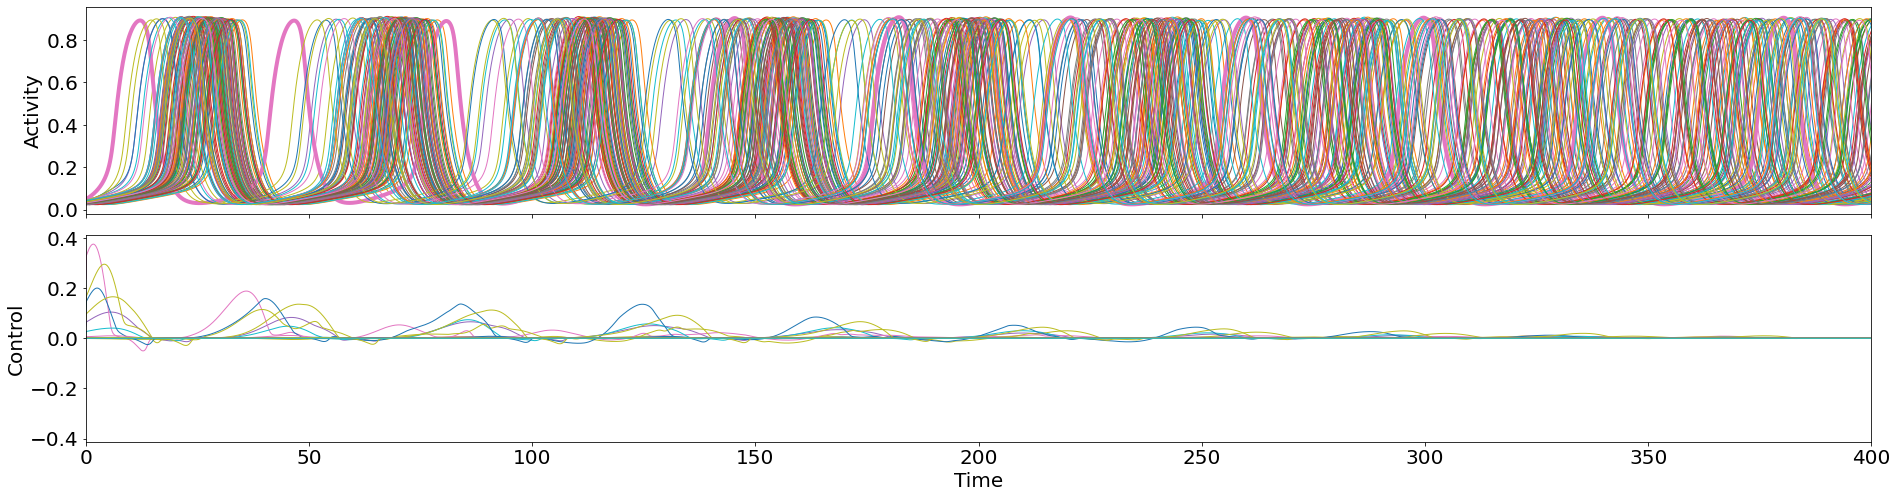

------------------------------------------------------------ wi =  30 -62.0
Optimal control with target oscillation period
Compute control for a deterministic system
Cost in iteration 0: 38.734484936501836
Final cost : 38.734484936501836
Compute control for a deterministic system
Cost in iteration 0: 13.304161976119289
Final cost : 13.304161976119289
Compute control for a deterministic system
Cost in iteration 0: 13.304161976119289
Cost in iteration 1: 13.304161976119289
Cost in iteration 2: 13.304161976119087
Cost in iteration 3: 13.304161976119087
Cost in iteration 4: 13.304161976119087
Converged in iteration 4 with cost 13.304161976119087
Final cost : 13.304161976119087
Compute control for a deterministic system
Cost in iteration 0: 13.304161976119087
Cost in iteration 1: 13.304022506549714
Cost in iteration 2: 13.304002401413205
Cost in iteration 3: 13.304002401413205
Cost in iteration 4: 13.304002401413205
Converged in iteration 4 with cost 13.304002401413205
Final cost : 13.30400

Compute control for a deterministic system
Cost in iteration 0: 12.781161029770239
Cost in iteration 1: 12.781161029770239
Cost in iteration 2: 12.781161029770239
Converged in iteration 2 with cost 12.781161029770239
Final cost : 12.781161029770239
Compute control for a deterministic system
Cost in iteration 0: 12.781161029770239
Cost in iteration 1: 12.781161029770239
Cost in iteration 2: 12.781161029770239
Converged in iteration 2 with cost 12.781161029770239
Final cost : 12.781161029770239
Compute control for a deterministic system
Cost in iteration 0: 12.781161029770239
Cost in iteration 1: 12.773333482830408
Cost in iteration 2: 12.773271147684376
Cost in iteration 3: 12.773209739154865
Cost in iteration 4: 12.773149242653961
Cost in iteration 5: 12.773089643768351
Cost in iteration 6: 12.773030928258962
Final cost : 12.773030928258962
Compute control for a deterministic system
Cost in iteration 0: 12.773030928258962
Cost in iteration 1: 12.772969177441144
Cost in iteration 2: 12.

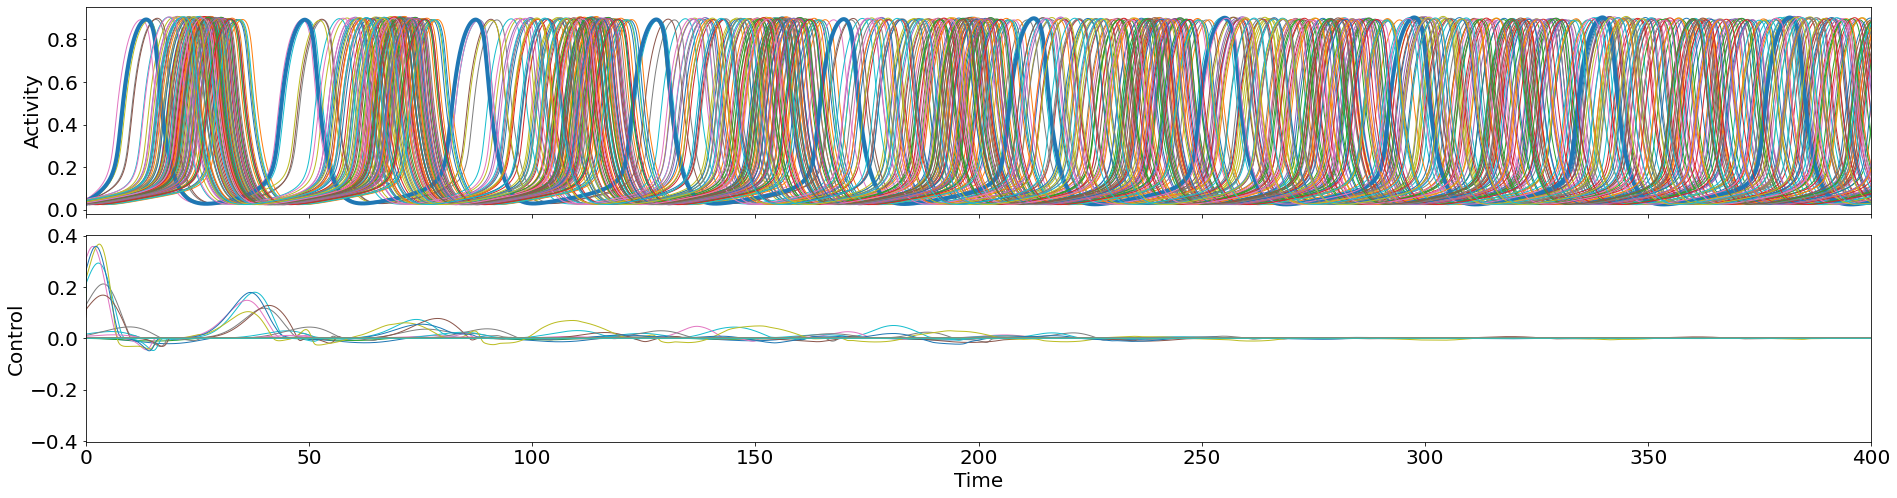

------------------------------------------------------------ wi =  35 -72.0
Optimal control with target oscillation period
Compute control for a deterministic system
Cost in iteration 0: 44.98198250690542
Final cost : 44.98198250690542
Compute control for a deterministic system
Cost in iteration 0: 14.39034142001808
Final cost : 14.39034142001808
Compute control for a deterministic system
Cost in iteration 0: 14.39034142001808
Cost in iteration 1: 14.390324321600637
Cost in iteration 2: 14.39029876811459
Cost in iteration 3: 14.39029876811459
Cost in iteration 4: 14.39029876811459
Converged in iteration 4 with cost 14.39029876811459
Final cost : 14.39029876811459
Compute control for a deterministic system
Cost in iteration 0: 14.39029876811459
Cost in iteration 1: 14.389572961330614
Cost in iteration 2: 14.389539744032803
Cost in iteration 3: 14.389507942493262
Cost in iteration 4: 14.389477480247004
Cost in iteration 5: 14.389448284918863
Cost in iteration 6: 14.389420288015206
Final 

Compute control for a deterministic system
Cost in iteration 0: 14.24288765524689
Cost in iteration 1: 14.227384423959478
Cost in iteration 2: 14.227384423845423
Cost in iteration 3: 14.227384423845423
Cost in iteration 4: 14.227384423845423
Converged in iteration 4 with cost 14.227384423845423
Final cost : 14.227384423845423
Compute control for a deterministic system
Cost in iteration 0: 14.227384423845423
Cost in iteration 1: 14.227372310446546
Cost in iteration 2: 14.22737231044654
Cost in iteration 3: 14.22737231044654
Cost in iteration 4: 14.22737231044654
Converged in iteration 4 with cost 14.22737231044654
Final cost : 14.22737231044654
Compute control for a deterministic system
Cost in iteration 0: 14.22737231044654
Cost in iteration 1: 14.227257954879565
Cost in iteration 2: 14.227257953446376
Cost in iteration 3: 14.227257953446376
Cost in iteration 4: 14.227257953446376
Converged in iteration 4 with cost 14.227257953446376
Final cost : 14.227257953446376
Compute control for 

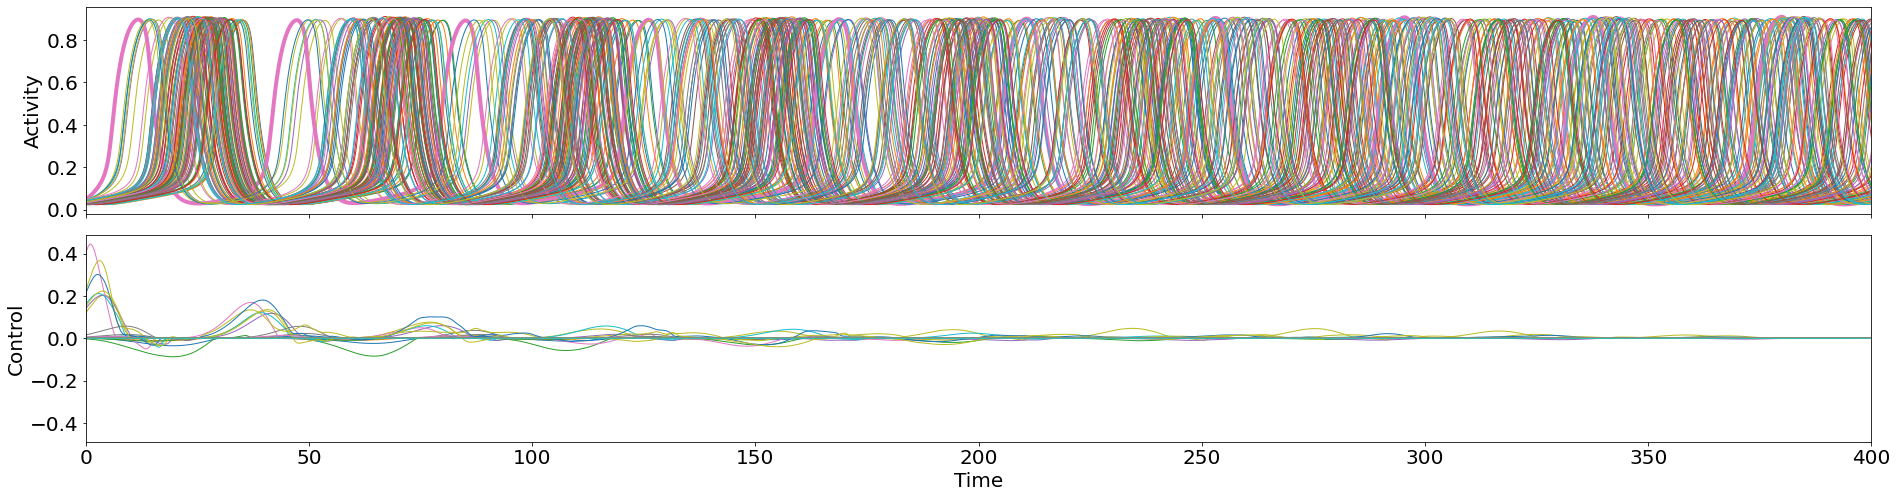

------------------------------------------------------------ wi =  40 -82.0
Optimal control with target oscillation period
Compute control for a deterministic system
Cost in iteration 0: 51.229480077309
Final cost : 51.229480077309
Compute control for a deterministic system
Cost in iteration 0: 15.524005731003133
Final cost : 15.524005731003133
Compute control for a deterministic system
Cost in iteration 0: 15.524005731003133
Cost in iteration 1: 15.524002691380685
Cost in iteration 2: 15.524002691380602
Cost in iteration 3: 15.524002691380584
Cost in iteration 4: 15.524002691380584
Cost in iteration 5: 15.524002691380584
Converged in iteration 5 with cost 15.524002691380584
Final cost : 15.524002691380584
Compute control for a deterministic system
Cost in iteration 0: 15.524002691380584
Cost in iteration 1: 15.524002288719242
Cost in iteration 2: 15.524002277396578
Cost in iteration 3: 15.524002277396576
Cost in iteration 4: 15.524002277396576
Cost in iteration 5: 15.524002277396576
C

In [ ]:
it = 6
d = data_0_L1
n_input_list = []

for wi in [3, 5, 10, 15, 20, 30, 35, 40, 45, 50, 55, 60, 65]:
    print("------------------------------------------------------------ wi = ", wi, d["weights"][wi])
    
    model = WCModel(Cmat=cmat_av, Dmat=dmat_av, seed=0)
    model.params.exc_init = d["init_state"][0]
    model.params.inh_init = d["init_state"][1]
    setparams(model)

    model.params["exc_ext_baseline"] =  d["coordinates"][0]
    model.params["inh_ext_baseline"] =  d["coordinates"][1]
    model.params.duration = duration

    model.run()

    model_controlled = oc_wc.OcWc(model, target_period, print_array=pr, cost_interval=(int0, int1), control_interval=(int0, int1), cost_matrix=costmat, control_matrix=controlmat)
    model_controlled.weights["w_p"] = 0.
    model_controlled.weights["w_1D"] = 1.
    model_controlled.weights["w_cc"] = d["weights"][wi]
    model_controlled.maximum_control_strength = max_cntrl
    
    model_controlled.optimize(0)

    if type(d["control"][wi]) != type(None):
        if d["control"][wi].ndim == 2:
            model_controlled.control = d["control"][wi].copy()
            model_controlled.update_input()

    model_controlled.channelwise_optimization = True
    model_controlled.optimize(0)
    
    cost0 = model_controlled.compute_total_cost()
    
    if convergence[wi] == 0:

        for j in range(10):
            model_controlled.grad_method = 0
            optimize_model(model_controlled, [-6, 0, 6, -2], wi, it)
            #model_controlled.grad_method = 1
            #optimize_model(model_controlled, [-6, 0, 6, -2], wi, it)

            cost1 = model_controlled.compute_total_cost()
            if np.abs(cost1 - cost0) < 1e-12:
                convergence[wi] = 1
                break
                
            cost0 = model_controlled.compute_total_cost()
    
    maxnodeind = np.argmax(np.sum(d["control"][wi]**2, axis=1))
    n_input = 0
    for n in range(N):
        if np.sum(d["control"][wi][n,:]**2) > 1e-1:
            n_input += 1
    n_input_list.append(n_input)
    
    print("max node ind, input nodes = ", maxnodeind, n_input)
    plot_control(model_controlled.control, model_controlled.get_xs(), duration, dt, fat=[maxnodeind], filename=None, title=None)

In [ ]:
print(n_input_list)     #[0, 10, 15, 20, 30, 35, 40, 45, 50, 55, 60]

In [18]:
print(n_input_list)

[1, 3, 4, 6, 7, 7, 10, 14, 15, 14, 15, 15, 16]


In [11]:
for wi in range(100):
    if wi not in [3, 5, 10, 15, 20, 30, 35, 40, 45, 50, 55, 60, 65]:
        d["control"][wi] = None

In [13]:
with open(os.path.join(datadir, 'wb_L1_cc_all_0.pickle'), 'rb') as f:
    data_read = pickle.load(f)

data_0_L1 = data_read

with open(os.path.join(datadir, 'wb_L1_cc_all_1.pickle'), 'rb') as f:
    data_read = pickle.load(f)

data_1_L1 = data_read

with open(os.path.join(datadir, 'wb_L1_cc_all_2.pickle'), 'rb') as f:
    data_read = pickle.load(f)

data_2_L1 = data_read

with open(os.path.join(datadir, 'wb_L1_cc.pickle'), 'wb') as f:
    pickle.dump([data_0_L1, data_1_L1, data_2_L1], f)

In [14]:
with open(os.path.join(datadir, 'wb_L1_all.pickle'), 'rb') as f:
    data_read = pickle.load(f)

d0 = data_read

with open(os.path.join(datadir, 'wb_L1_all_1.pickle'), 'rb') as f:
    data_read = pickle.load(f)

d1 = data_read

with open(os.path.join(datadir, 'wb_L1_all_2.pickle'), 'rb') as f:
    data_read = pickle.load(f)

d2 = data_read

with open(os.path.join(datadir, 'wb_L1.pickle'), 'wb') as f:
    pickle.dump([d0, d1, d2], f)